### **WP3.1 - modelling dataset preparation**

This notebook converts the engineered WP2.3 dataset into patient-split, model-ready matrices for all WP3 modelling notebooks.


##### **Notebook Outline**

- **matrix setup:** load the engineered dataset and define predictors, labels, identifiers, and modelling context.
- **patient-level split:** split admissions by patient so the same patient cannot appear in train and test sets.
- **preprocessing:** fit imputation, scaling, and categorical encoding on the training data only.
- **feature-audit matrices:** save full, clean-audit, runtime-trimmed, and SHAP-guided reduced matrices for later comparison.


In [ ]:
#import libraries used for wp3.1 preprocessing and processed-feature audit
import sys
import json
import warnings
import shutil
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from joblib import dump
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from collections import Counter
import re

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print(sys.executable)

/Users/ahthini/Desktop/DissProject/my_env/bin/python


**Load engineered admission-level dataset and define paths**

All WP3.1 input/output folders are defined here so the preprocessing and feature-audit sections use one shared path setup. The admission-level dataset produced in WP2.3 is used as the modelling source. Each row represents one hospital admission, and the outcome is 30-day psychiatric readmission.




In [2]:
#define shared project paths and output folders used across wp3.1
current_path = Path.cwd().resolve()
project_path = None
for candidate_path in [current_path] + list(current_path.parents):
    if (candidate_path / "code").exists():
        project_path = candidate_path
        break
if project_path is None:
    project_path = Path("/Users/ahthini/Desktop/DissProject")
output_path = project_path / "outputs"
wp3_1_output_path = output_path / "WP3_1"
wp3_2_output_path = output_path / "WP3_2"
wp3_3_output_path = output_path / "WP3_3"
wp3_4_output_path = output_path / "WP3_4"
wp3_feature_audit_output_path = output_path / "WP3_feature_audit"

wp3_1_output_path.mkdir(parents=True, exist_ok=True)
wp3_feature_audit_output_path.mkdir(parents=True, exist_ok=True)

#input/output files used by the preprocessing and audit sections
engineered_dataset_file = output_path / "t2_3_engineered_dataset.csv"
x_train_path = wp3_1_output_path / "t3_1_X_train_processed.npz"
x_test_path = wp3_1_output_path / "t3_1_X_test_processed.npz"
y_train_path = wp3_1_output_path / "t3_1_y_train.csv"
y_test_path = wp3_1_output_path / "t3_1_y_test.csv"
feature_names_path = wp3_1_output_path / "t3_1_processed_feature_names.csv"
feature_lists_path = wp3_1_output_path / "t3_1_feature_lists.json"

#load final engineered admission-level dataset from wp2.3
df = pd.read_csv(engineered_dataset_file, low_memory=False)
print("Loaded engineered dataset shape:")
print(df.shape)
print("Number of unique patients:")
print(df["subject_id"].nunique())
print("Number of unique admissions:")
print(df["hadm_id"].nunique())
print("Readmission outcome distribution:")
print(df["readmitted_30d"].value_counts())
print("Readmission outcome distribution (%):")
print((df["readmitted_30d"].value_counts(normalize=True) * 100).round(2))
print("WP3.1 output folder:", wp3_1_output_path)
print("WP3 feature audit output folder:", wp3_feature_audit_output_path)

Loaded engineered dataset shape:
(238491, 1442)
Number of unique patients:
107926
Number of unique admissions:
238491
Readmission outcome distribution:
readmitted_30d
0    191133
1     47358
Name: count, dtype: int64
Readmission outcome distribution (%):
readmitted_30d
0    80.14
1    19.86
Name: proportion, dtype: float64
WP3.1 output folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_1
WP3 feature audit output folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_feature_audit


**Check admission-level structure and outcome validity**

Before splitting the dataset, the admission identifiers and outcome values are checked. Duplicate admission rows would invalidate model evaluation because the same admission could appear in multiple folds or splits.

In [3]:
#run check admission-level structure and outcome validity before splitting the dataset, the adm
print("Duplicate subject_id + hadm_id rows:")
print(df.duplicated(subset=["subject_id", "hadm_id"]).sum())

print("\nMissing outcome values:")
print(df["readmitted_30d"].isna().sum())

print("\nUnique outcome values:")
print(sorted(df["readmitted_30d"].dropna().unique()))

print("\nMissing values remaining in full engineered dataset:")
remaining_missing = df.isna().sum().sort_values(ascending=False)
print(remaining_missing[remaining_missing > 0].head(20))

Duplicate subject_id + hadm_id rows:
0

Missing outcome values:
0

Unique outcome values:
[np.int64(0), np.int64(1)]

Missing values remaining in full engineered dataset:
ed_to_ward_delay_hours                     234979
first_safety_order_hours_from_admission    195613
last_safety_order_hours_from_admission     195613
days_since_previous_icu_admission          189921
time_to_first_transfer_hours               186036
height_change_recent                       160681
previous_height_cm_before_admission        160681
bmi_change_recent                          134143
previous_bmi_before_admission              134143
time_between_last_two_admissions_days      128201
mean_previous_admission_gap_days           128201
min_previous_admission_gap_days            128201
std_previous_admission_gap_days            128201
weight_change_recent                       123210
previous_weight_kg_before_admission        123210
latest_height_cm_before_admission          111956
previous_dischtime           

**Define modelling predictors and remove identifier/leakage fields**

Identifiers, raw timestamps, and fields that directly encode future information are removed from the predictor matrix. Patient identifiers are retained separately only for group-aware splitting. The raw `days_since_previous_psych_admission` column is excluded because WP2.3 already created a filled version and a categorical recency feature for modelling.

In [4]:
#target and grouping variable
target_col = "readmitted_30d"
group_col = "subject_id"

#columns excluded from predictors
#identifiers, raw timestamps, and direct future-outcome fields are never used as model inputs.
#discharge-context predictors are kept for the full-record benchmark after WP2 masks death/hospice destinations
#direct future-outcome fields and hospital expiry fields remain excluded from all predictor matrices
exclude_cols = ["subject_id", "hadm_id", "readmitted_30d", "readmitted_30d_psych",
    "readmitted_60d_psych", "readmitted_90d_psych", "readmitted_365d_psych",
    "readmitted_30d_any", "readmitted_60d_any", "readmitted_90d_any", "readmitted_365d_any",
    "admittime", "dischtime", "deathtime", "previous_dischtime", "next_admittime", "next_is_psych",
    "days_to_next", "days_since_previous_psych_admission", "hospital_expire_flag",]

#keep only exclusions that exist in the current dataset
exclude_cols = [col for col in exclude_cols if col in df.columns]
feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()
groups = df[group_col].copy()

print("Number of excluded columns:", len(exclude_cols))
print(exclude_cols)
print("\nNumber of candidate predictor columns:", len(feature_cols))
print("\nPredictor preview:")
print(X.head())

Number of excluded columns: 7
['subject_id', 'hadm_id', 'readmitted_30d', 'admittime', 'dischtime', 'previous_dischtime', 'days_since_previous_psych_admission']

Number of candidate predictor columns: 1435

Predictor preview:
  gender  anchor_age anchor_year_group  admission_type      admission_location      discharge_location insurance language marital_status   race  hospital_los_days  \
0      F          52       2014 - 2016          URGENT  TRANSFER FROM HOSPITAL                    HOME  Medicaid  English        WIDOWED  WHITE           0.786111   
1      F          52       2014 - 2016        EW EMER.          EMERGENCY ROOM                    HOME  Medicaid  English        WIDOWED  WHITE           1.015278   
2      F          52       2014 - 2016        EW EMER.          EMERGENCY ROOM                    HOME  Medicaid  English        WIDOWED  WHITE           2.222222   
3      F          52       2014 - 2016        EW EMER.          EMERGENCY ROOM  Unknown / not modelled  Medica

**Create patient-level train/test split**

Admissions from the same patient must remain in the same split to avoid patient-level information leakage. A group-aware split is therefore used with `subject_id` as the grouping variable.

In [5]:
#patient-level split to prevent admissions from the same patient appearing in both train and test sets
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_ids = df.iloc[train_idx][["subject_id", "hadm_id", "readmitted_30d"]].copy()
test_ids = df.iloc[test_idx][["subject_id", "hadm_id", "readmitted_30d"]].copy()

#add secondary outcome-window labels to the split metadata only
#these labels let wp3.5 ask whether a 30-day psychiatric readmission model also ranks later psychiatric readmission risk.
#they are deliberately kept out of the predictor matrix to avoid leakage.
cohort_timing_file = output_path / "psychiatric_readmission_cohort.csv"
extended_outcome_cols = []
if cohort_timing_file.exists():
    cohort_timing_df = pd.read_csv(cohort_timing_file,
        usecols=["subject_id", "hadm_id", "days_to_next", "next_is_psych"])
    cohort_timing_df["next_is_psych"] = cohort_timing_df["next_is_psych"].fillna(0).astype(int)
    #loop through each item in this feature block
    for outcome_window_days in [30, 60, 90, 365]:
        cohort_timing_df[f"readmitted_{outcome_window_days}d_psych"] = (
            (cohort_timing_df["next_is_psych"] == 1) &
            cohort_timing_df["days_to_next"].between(0, outcome_window_days, inclusive="both")).astype(int)
        cohort_timing_df[f"readmitted_{outcome_window_days}d_any"] = (
            cohort_timing_df["days_to_next"].between(0, outcome_window_days, inclusive="both")).astype(int)

    extended_outcome_cols = [f"readmitted_{days}d_psych" for days in [30, 60, 90, 365]] + [
        f"readmitted_{days}d_any" for days in [30, 60, 90, 365]]
    timing_outcome_cols = ["subject_id", "hadm_id", "days_to_next", "next_is_psych"] + extended_outcome_cols
    #join the derived features back to the admission table
    train_ids = train_ids.merge(cohort_timing_df[timing_outcome_cols], on=["subject_id", "hadm_id"], how="left")
    test_ids = test_ids.merge(cohort_timing_df[timing_outcome_cols], on=["subject_id", "hadm_id"], how="left")

    #keep the original target as the authoritative 30-day training label, while exposing the timing-derived check
    for split_ids in [train_ids, test_ids]:
        split_ids["readmitted_30d_psych"] = split_ids["readmitted_30d_psych"].fillna(split_ids["readmitted_30d"]).astype(int)
        #loop through each item in this feature block
        for col in extended_outcome_cols:
            split_ids[col] = split_ids[col].fillna(0).astype(int)

    print("Secondary psychiatric outcome-window labels added to train/test ID files.")
else:
    print("Secondary outcome-window labels skipped because the cohort timing file is unavailable.")

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nUnique patients in training set:", train_ids["subject_id"].nunique())
print("Unique patients in test set:", test_ids["subject_id"].nunique())
print("\nPatient overlap between train and test:")
print(len(set(train_ids["subject_id"]).intersection(set(test_ids["subject_id"]))))

print("\nTraining outcome distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest outcome distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Secondary psychiatric outcome-window labels added to train/test ID files.
Training set shape: (191320, 1435)
Test set shape: (47171, 1435)

Unique patients in training set: 86340
Unique patients in test set: 21586

Patient overlap between train and test:
0

Training outcome distribution:
readmitted_30d
0    153281
1     38039
Name: count, dtype: int64
readmitted_30d
0    80.12
1    19.88
Name: proportion, dtype: float64

Test outcome distribution:
readmitted_30d
0    37852
1     9319
Name: count, dtype: int64
readmitted_30d
0    80.24
1    19.76
Name: proportion, dtype: float64


**Identify numerical and categorical predictors**

Categorical predictors are one-hot encoded. Numerical predictors are median-imputed and standardised. The preprocessing pipeline is fitted on the training set only, then applied to the test set.

In [6]:
#identify feature types
categorical_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

#coerce numerical columns safely
for col in numerical_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

print("Number of numerical predictors:", len(numerical_cols))
print("Number of categorical predictors:", len(categorical_cols))
print("\nCategorical predictors:")
print(categorical_cols)
print("\nFirst 30 numerical predictors:")
print(numerical_cols[:30])

Number of numerical predictors: 1397
Number of categorical predictors: 38

Categorical predictors:
['gender', 'anchor_year_group', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'first_icu_careunit', 'last_icu_careunit', 'icu_type', 'first_service', 'last_service', 'infection_burden_category', 'bmi_category', 'last_careunit_before_discharge', 'time_since_previous_psych_category', 'age_group', 'hospital_los_category', 'admission_season', 'discharge_season', 'discharge_location_grouped', 'admission_location_grouped', 'insurance_grouped', 'psych_diagnosis_burden_category', 'nonpsych_diagnosis_burden_category', 'total_diagnosis_burden_category', 'drg_severity_category', 'drg_mortality_category', 'service_transfer_category', 'physical_transfer_category', 'procedure_burden_category', 'psych_medication_burden_category', 'unique_drug_burden_category', 'lab_abnormal_burden_category', 'icu_utilisation_category', 'physiological_ins

**Build preprocessing pipeline**

The preprocessing pipeline handles missing values, scaling, and categorical encoding in a reproducible way. This fitted pipeline is saved so the exact same transformations can be reused in WP3.2 and later modelling notebooks.

In [7]:
#preprocessing for numerical and categorical variables
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))])

preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)])

print("Preprocessing pipeline created.")
print(preprocessor)

Preprocessing pipeline created.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['anchor_age', 'hospital_los_days',
                                  'discharged_against_advice',
                                  'not_married_flag',
                                  'single_or_divorced_or_widowed',
                                  'non_english_language_flag',
                                  'public_insurance_flag', 'medicaid_flag',
                                  'medicare_flag', 'insurance_missing_flag...
                                  'time_since_previous_psych_category',
                                  'age_group', 'hospital_los_category',
                                  'admission_season', 'discharge_season',
             

**Fit preprocessing on training data and transform train/test matrices**

Only the training data are used to fit imputers, scalers, and one-hot encoders. The test set is transformed using the fitted training transformations.

In [8]:
#fit on train only, transform train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training matrix shape:", X_train_processed.shape)
print("Processed test matrix shape:", X_test_processed.shape)
print("\nProcessed matrix type:")
print(type(X_train_processed))

Processed training matrix shape: (191320, 1688)
Processed test matrix shape: (47171, 1688)

Processed matrix type:
<class 'numpy.ndarray'>


**Extract processed feature names**

Feature names are saved for model interpretation, coefficient review, and feature-importance reporting.

In [9]:
#extract transformed feature names
processed_feature_names = preprocessor.get_feature_names_out()
processed_feature_names = pd.Series(processed_feature_names, name="processed_feature_name")

print("Number of processed features:", len(processed_feature_names))
print("\nFirst 30 processed feature names:")
print(processed_feature_names.head(30).to_string(index=False))

Number of processed features: 1688

First 30 processed feature names:
                             num__anchor_age
                      num__hospital_los_days
              num__discharged_against_advice
                       num__not_married_flag
          num__single_or_divorced_or_widowed
              num__non_english_language_flag
                  num__public_insurance_flag
                          num__medicaid_flag
                          num__medicare_flag
                 num__insurance_missing_flag
            num__admitted_from_facility_flag
   num__admitted_from_hospital_transfer_flag
          num__emergency_room_admission_flag
            num__transfer_from_hospital_flag
                 num__transfer_from_snf_flag
      num__internal_transfer_from_psych_flag
                   num__discharged_home_flag
            num__discharged_to_facility_flag
      num__discharged_to_psych_facility_flag
                       num__los_under_2_days
                       num__lo

**Class imbalance summary**

The readmission outcome is imbalanced, so WP3 models should use class-weighted approaches and report threshold-independent metrics such as AUROC and AUPRC. Class weights are calculated here for reuse in later modelling notebooks.

In [10]:
#calculate simple class imbalance values for later models
n_negative = int((y_train == 0).sum())
n_positive = int((y_train == 1).sum())
scale_pos_weight = n_negative / n_positive

class_weight_summary = pd.DataFrame({
    "metric": ["training_negative_cases", "training_positive_cases", "positive_class_percent", "scale_pos_weight"],
    "value": [n_negative, n_positive, round((n_positive / len(y_train)) * 100, 2), round(scale_pos_weight, 4)]})

print("Class imbalance summary:")
print(class_weight_summary)

Class imbalance summary:
                    metric        value
0  training_negative_cases  153281.0000
1  training_positive_cases   38039.0000
2   positive_class_percent      19.8800
3         scale_pos_weight       4.0296


**Save WP3.1 modelling preparation outputs**

The transformed matrices are saved as sparse `.npz` files to avoid unnecessarily large CSV files. Split identifiers, target labels, feature names, feature lists, and the fitted preprocessing pipeline are saved separately for reproducibility.

In [11]:
#save split metadata, processed matrices, feature names, and fitted preprocessor
X_train_file = wp3_1_output_path / "t3_1_X_train_processed.npz"
X_test_file = wp3_1_output_path / "t3_1_X_test_processed.npz"
y_train_file = wp3_1_output_path / "t3_1_y_train.csv"
y_test_file = wp3_1_output_path / "t3_1_y_test.csv"
train_ids_file = wp3_1_output_path / "t3_1_train_ids.csv"
test_ids_file = wp3_1_output_path / "t3_1_test_ids.csv"
feature_names_file = wp3_1_output_path / "t3_1_processed_feature_names.csv"
feature_lists_file = wp3_1_output_path / "t3_1_feature_lists.json"
preprocessor_file = wp3_1_output_path / "t3_1_preprocessor.joblib"
class_weight_file = wp3_1_output_path / "t3_1_class_weight_summary.csv"
extended_train_outcomes_file = wp3_1_output_path / "t3_1_train_extended_outcomes.csv"
extended_test_outcomes_file = wp3_1_output_path / "t3_1_test_extended_outcomes.csv"

#save this table or artefact for later review
sparse.save_npz(X_train_file, sparse.csr_matrix(X_train_processed))
sparse.save_npz(X_test_file, sparse.csr_matrix(X_test_processed))
y_train.to_frame(name="readmitted_30d").to_csv(y_train_file, index=False)
y_test.to_frame(name="readmitted_30d").to_csv(y_test_file, index=False)
train_ids.to_csv(train_ids_file, index=False)
test_ids.to_csv(test_ids_file, index=False)
extended_outcome_export_cols = [col for col in train_ids.columns if col.startswith("readmitted_")]
if extended_outcome_export_cols:
    #save this table or artefact for later review
    train_ids[["subject_id", "hadm_id"] + extended_outcome_export_cols].to_csv(extended_train_outcomes_file, index=False)
    test_ids[["subject_id", "hadm_id"] + extended_outcome_export_cols].to_csv(extended_test_outcomes_file, index=False)
processed_feature_names.to_csv(feature_names_file, index=False)
class_weight_summary.to_csv(class_weight_file, index=False)
dump(preprocessor, preprocessor_file)

source_dataset_metadata = {"source_dataset_file": str(engineered_dataset_file),
    "source_dataset_modified_time": pd.to_datetime(engineered_dataset_file.stat().st_mtime, unit="s").isoformat(),
    "source_dataset_size_mb": round(engineered_dataset_file.stat().st_size / (1024 ** 2), 3),}

feature_lists = {"excluded_columns": exclude_cols,
    "original_feature_columns": feature_cols, "numerical_columns": numerical_cols,
    "categorical_columns": categorical_cols, "target_column": target_col,
    "group_column": group_col, "random_state": 42, "test_size": 0.20,
    "modelling_context": "full_record_benchmark", **source_dataset_metadata}

with open(feature_lists_file, "w") as f:
    json.dump(feature_lists, f, indent=2)

print("Saved WP3.1 outputs:")
for path in [X_train_file, X_test_file, y_train_file, y_test_file, train_ids_file, test_ids_file,
    extended_train_outcomes_file, extended_test_outcomes_file, feature_names_file, feature_lists_file,
    preprocessor_file, class_weight_file]:
    print(path)

Saved WP3.1 outputs:
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_X_train_processed.npz
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_X_test_processed.npz
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_y_train.csv
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_y_test.csv
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_train_ids.csv
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_test_ids.csv
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_train_extended_outcomes.csv
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_test_extended_outcomes.csv
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_processed_feature_names.csv
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_feature_lists.json
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_preprocessor.joblib
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_class_weight_summary.csv


**Methodological audit for modelling split**

This audit records the modelling context and split checks used to guard against patient overlap and accidental outcome leakage. The benchmark is a full-record discharge-time task, so discharge-context features are allowed, but future readmission labels and timing fields are not used as predictors.


In [12]:
#record split, outcome, and prediction-context checks for method reporting
train_patient_set = set(train_ids["subject_id"])
test_patient_set = set(test_ids["subject_id"])
patient_overlap_count = len(train_patient_set.intersection(test_patient_set))

#confirm secondary outcome-window labels are metadata only, not predictors
secondary_outcome_predictor_overlap = sorted(set(feature_cols).intersection(set(extended_outcome_cols))) if extended_outcome_cols else []
future_timing_predictor_overlap = sorted(set(feature_cols).intersection({"days_to_next", "next_admittime", "next_is_psych"}))

audit_rows = [{"check": "prediction_context", "value": "full_record_discharge_time_benchmark"},
    {"check": "unit_of_prediction", "value": "admission"},
    {"check": "split_level", "value": "patient_level_group_split"},
    {"check": "train_rows", "value": X_train.shape[0]},
    {"check": "test_rows", "value": X_test.shape[0]},
    {"check": "train_patients", "value": len(train_patient_set)},
    {"check": "test_patients", "value": len(test_patient_set)},
    {"check": "patient_overlap_between_train_test", "value": patient_overlap_count},
    {"check": "target_column", "value": target_col},
    {"check": "train_readmission_rate", "value": round(float(y_train.mean()), 4)},
    {"check": "test_readmission_rate", "value": round(float(y_test.mean()), 4)},
    {"check": "candidate_predictor_columns", "value": len(feature_cols)},
    {"check": "processed_predictor_columns", "value": len(processed_feature_names)},
    {"check": "secondary_outcome_predictor_overlap", "value": ";".join(secondary_outcome_predictor_overlap)},
    {"check": "future_timing_predictor_overlap", "value": ";".join(future_timing_predictor_overlap)},
    {"check": "test_set_role", "value": "held_out_final_reporting_only"}]

methodological_audit_df = pd.DataFrame(audit_rows)
methodological_audit_file = wp3_1_output_path / "t3_1_methodological_audit.csv"
methodological_audit_df.to_csv(methodological_audit_file, index=False)

print("WP3.1 methodological audit saved to:")
print(methodological_audit_file)
display(methodological_audit_df)

WP3.1 methodological audit saved to:
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_methodological_audit.csv


,check,value
0,prediction_context,full_record_discharge_time_benchmark
1,unit_of_prediction,admission
2,split_level,patient_level_group_split
3,train_rows,191320
4,test_rows,47171
5,train_patients,86340
6,test_patients,21586
7,patient_overlap_between_train_test,0
8,target_column,readmitted_30d
9,train_readmission_rate,0.1988


**Create Clean Feature-Audit Matrices**

These files use the same patient-level train/test split and fitted preprocessing pipeline as the full WP3.1 matrices, but remove processed features that are not suitable for the cleaner primary benchmark.

Death/hospice discharge destinations are masked upstream in WP2.3 because they can act as competing-risk shortcuts rather than psychiatric readmission predictors. The same patterns are still listed here as a safety check in case an older engineered dataset or shifted category name reaches WP3.1.


In [13]:
#create clean processed matrices from the same train/test split
#keep death/hospice patterns here as a downstream safety check after the WP2.3 masking step
clean_feature_audit_remove_features = [
    "num__discharged_to_death_or_hospice",
    "cat__discharge_location_DIED",
    "cat__discharge_location_HOSPICE",
    "cat__discharge_location_grouped_Hospice / died",
    "num__abnormal_microbiology_interpretation",
    "num__had_restraint_related_procedure",
    "num__had_suicide_precaution_order",
    "num__had_elopement_precaution_order",
    "num__had_restraint_order",
    "num__sodium_lab_severe_abnormal"]

processed_feature_name_list = processed_feature_names.tolist()
missing_clean_remove_features = [feature for feature in clean_feature_audit_remove_features
    if feature not in processed_feature_name_list]
clean_keep_mask = np.array([feature not in clean_feature_audit_remove_features
    for feature in processed_feature_name_list])
clean_processed_feature_names = processed_feature_names.loc[clean_keep_mask].reset_index(drop=True)
removed_clean_processed_feature_names = processed_feature_names.loc[~clean_keep_mask].reset_index(drop=True)

X_train_processed_clean = sparse.csr_matrix(X_train_processed)[:, clean_keep_mask]
X_test_processed_clean = sparse.csr_matrix(X_test_processed)[:, clean_keep_mask]

clean_X_train_file = wp3_1_output_path / "t3_1_X_train_processed_clean_feature_audit.npz"
clean_X_test_file = wp3_1_output_path / "t3_1_X_test_processed_clean_feature_audit.npz"
clean_feature_names_file = wp3_1_output_path / "t3_1_processed_feature_names_clean_feature_audit.csv"
clean_removed_features_file = wp3_1_output_path / "t3_1_removed_processed_feature_names_clean_feature_audit.csv"
clean_summary_file = wp3_1_output_path / "t3_1_clean_feature_audit_summary.csv"

#save this table or artefact for later review
sparse.save_npz(clean_X_train_file, X_train_processed_clean)
sparse.save_npz(clean_X_test_file, X_test_processed_clean)
clean_processed_feature_names.to_csv(clean_feature_names_file, index=False)
removed_clean_processed_feature_names.to_frame(name="processed_feature_name").to_csv(
    clean_removed_features_file, index=False)

clean_feature_audit_summary = pd.DataFrame({"check": [
        "Original processed features", "Clean processed features", "Removed processed features",
        "Training admissions", "Test admissions", "Missing requested clean-removal features"],
    "value": [len(processed_feature_names), len(clean_processed_feature_names),
        len(removed_clean_processed_feature_names), X_train_processed_clean.shape[0],
        X_test_processed_clean.shape[0], len(missing_clean_remove_features)]})
clean_feature_audit_summary.to_csv(clean_summary_file, index=False)

print("Clean feature-audit matrices saved:")
print(clean_X_train_file)
print(clean_X_test_file)
print(clean_feature_names_file)
print(clean_removed_features_file)
print(clean_summary_file)
print()
print("Clean matrix shapes:", X_train_processed_clean.shape, X_test_processed_clean.shape)
print("Removed clean features:")
print(removed_clean_processed_feature_names.to_string(index=False))
if missing_clean_remove_features:
    print()
    print("Requested clean-removal features not present:")
    print(missing_clean_remove_features)

Clean feature-audit matrices saved:
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_X_train_processed_clean_feature_audit.npz
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_X_test_processed_clean_feature_audit.npz
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_processed_feature_names_clean_feature_audit.csv
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_removed_processed_feature_names_clean_feature_audit.csv
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_clean_feature_audit_summary.csv

Clean matrix shapes: (191320, 1682) (47171, 1682)
Removed clean features:
          num__sodium_lab_severe_abnormal
        num__had_suicide_precaution_order
      num__had_elopement_precaution_order
                 num__had_restraint_order
num__abnormal_microbiology_interpretation
     num__had_restraint_related_procedure

Requested clean-removal features not present:
['num__discharged_to_death_or_hospice', 'cat__discharge_location_DIED', 'cat__discharge_location_HOSP

Processed Feature Audit**

This section audits the processed train/test matrices created above. It checks feature sparsity, timing/leakage review flags, feature-family size, and recommended reduced matrix versions. The audit is kept inside WP3.1 because it belongs to preprocessing and processed-feature quality control rather than model training.




#### **Feature Audit Input Checks**

The audit uses the processed matrices saved earlier in WP3.1. This check confirms that the expected matrix, label, and feature-name files are available before the audit calculations run.




In [14]:
#check required processed matrix files before running the feature audit
required_paths = [x_train_path, x_test_path, y_train_path, y_test_path, feature_names_path]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required WP3.1 files:" + " ".join(missing_paths))

print("WP3.1 input folder:")
print(wp3_1_output_path)
print("WP3 feature audit output folder:")
print(wp3_feature_audit_output_path)

WP3.1 input folder:
/Users/ahthini/Desktop/DissProject/outputs/WP3_1
WP3 feature audit output folder:
/Users/ahthini/Desktop/DissProject/outputs/WP3_feature_audit


**Load WP3.1 processed modelling matrices**

The audit is performed after WP3.1 preprocessing, so the feature list reflects the actual columns seen by the machine learning models.

In [15]:
#load processed matrices, labels, and processed feature names created in wp3.1
X_train = sparse.load_npz(x_train_path).tocsr()
X_test = sparse.load_npz(x_test_path).tocsr()
y_train = pd.read_csv(y_train_path)["readmitted_30d"].astype(int)
y_test = pd.read_csv(y_test_path)["readmitted_30d"].astype(int)
feature_names_df = pd.read_csv(feature_names_path)

if "processed_feature_name" in feature_names_df.columns:
    processed_feature_names = feature_names_df["processed_feature_name"].astype(str).tolist()
else:
    processed_feature_names = feature_names_df.iloc[:, 0].astype(str).tolist()

if X_train.shape[1] != len(processed_feature_names):
    raise ValueError("The number of processed feature names does not match the training matrix columns.")

print("Training matrix shape:", X_train.shape)
print("Test matrix shape:", X_test.shape)
print("Number of processed features:", len(processed_feature_names))
print("Training outcome distribution:")
print(y_train.value_counts().sort_index())
print("\nTest outcome distribution:")
print(y_test.value_counts().sort_index())
print("\nTraining matrix sparsity (%):", round(100 * (1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])), 2))
print("Test matrix sparsity (%):", round(100 * (1 - X_test.nnz / (X_test.shape[0] * X_test.shape[1])), 2))

feature_audit_df = pd.DataFrame({"processed_feature_name": processed_feature_names})
feature_audit_df.head(10)

Training matrix shape: (191320, 1688)
Test matrix shape: (47171, 1688)
Number of processed features: 1688
Training outcome distribution:
readmitted_30d
0    153281
1     38039
Name: count, dtype: int64

Test outcome distribution:
readmitted_30d
0    37852
1     9319
Name: count, dtype: int64

Training matrix sparsity (%): 18.07
Test matrix sparsity (%): 18.07


,processed_feature_name
0,num__anchor_age
1,num__hospital_los_days
2,num__discharged_against_advice
3,num__not_married_flag
4,num__single_or_divorced_or_widowed
5,num__non_english_language_flag
6,num__public_insurance_flag
7,num__medicaid_flag
8,num__medicare_flag
9,num__insurance_missing_flag


**Assess processed feature sparsity**

Very rare one-hot encoded features can slow tree models and may add noise. These are flagged for review rather than automatically removed.

In [16]:
#calculate how often each processed feature is non-zero in the train and test matrices
train_nonzero_count = np.asarray(X_train.getnnz(axis=0)).ravel()
test_nonzero_count = np.asarray(X_test.getnnz(axis=0)).ravel()

feature_audit_df["train_nonzero_count"] = train_nonzero_count
feature_audit_df["test_nonzero_count"] = test_nonzero_count
feature_audit_df["train_nonzero_percent"] = 100 * feature_audit_df["train_nonzero_count"] / X_train.shape[0]
feature_audit_df["test_nonzero_percent"] = 100 * feature_audit_df["test_nonzero_count"] / X_test.shape[0]
feature_audit_df["all_zero_train"] = feature_audit_df["train_nonzero_count"].eq(0)
feature_audit_df["all_zero_test"] = feature_audit_df["test_nonzero_count"].eq(0)
feature_audit_df["very_rare_train"] = feature_audit_df["train_nonzero_percent"].lt(0.05)
feature_audit_df["rare_train"] = feature_audit_df["train_nonzero_percent"].lt(0.5)

print("All-zero processed features in training:", int(feature_audit_df["all_zero_train"].sum()))
print("Very rare processed features in training (<0.05% non-zero):", int(feature_audit_df["very_rare_train"].sum()))
print("Rare processed features in training (<0.5% non-zero):", int(feature_audit_df["rare_train"].sum()))

feature_audit_df.sort_values("train_nonzero_percent").head(30)

All-zero processed features in training: 52
Very rare processed features in training (<0.05% non-zero): 83
Rare processed features in training (<0.5% non-zero): 125


,processed_feature_name,train_nonzero_count,test_nonzero_count,train_nonzero_percent,test_nonzero_percent,all_zero_train,all_zero_test,very_rare_train,rare_train
1385,num__prior_ed_only_use_with_current_self_harm_...,0,0,0.0,0.0,True,True,True,True
1371,num__late_transport_or_placement_activity_flag,0,0,0.0,0.0,True,True,True,True
709,num__emar_psychotropic_refused_count,0,0,0.0,0.0,True,True,True,True
708,num__emar_refused_event_count,0,0,0.0,0.0,True,True,True,True
697,num__had_restraint_related_procedure,0,0,0.0,0.0,True,True,True,True
738,num__emar_psychotropic_refusal_rate,0,0,0.0,0.0,True,True,True,True
737,num__emar_refusal_rate,0,0,0.0,0.0,True,True,True,True
729,num__dose_due_to_given_gap_count,0,0,0.0,0.0,True,True,True,True
1087,num__discharge_planning_order_proportion,0,0,0.0,0.0,True,True,True,True
1217,num__discharge_planning_and_psych_followup_flag,0,0,0.0,0.0,True,True,True,True


**Flag possible leakage and timing-sensitive variables**

These flags separate direct outcome leakage from features that may be acceptable in the full-record benchmark but should be removed in a later early-prediction dataset.

In [17]:
#define pattern groups used to flag potential leakage or timing-sensitive features
leakage_pattern_groups = {"direct_future_outcome": [
        "readmitted_30d", "days_to_next", "next_admittime", "next_is_psych", "future_readmission"],
    "death_or_readmission_impossible": [
        "hospital_expire_flag", "deathtime", "discharge_location_DIED", "discharged_to_death_or_hospice", "_DIED", "hospice", "dod"],
    "post_discharge_context": ["discharge_location", "last_service", "last_icu_careunit"],
    "full_record_not_early_prediction": ["hospital_los_days", "total_icu_los_days", "icu_stay_count", "num_transfer_events", 
        "num_service_transfers", "num_careunit_transfers", "num_procedures", "num_prescription_rows", "lab_last_value",
        "vital_last_value", "lab_value_change", "vital_value_change", "lab_mean_value", "vital_mean_value", "lab_max_value",
        "vital_max_value", "lab_min_value", "vital_min_value", "last_order", "close_to_discharge",
        "before_discharge", "near_discharge", "after_72h", "order_activity_duration", "order_activity_last",
        "late_safety_order", "late_care_team", "previous_admission_had_late_orders",
        "num_lab_events_last_24h", "num_lab_events_last_48h", "lab_activity_near_discharge"],}

#find timing or leakage flags
def find_timing_or_leakage_flags(feature_name):
    lower_feature_name = feature_name.lower()
    matched_flags = []
    for flag_name, patterns in leakage_pattern_groups.items():
        if any(pattern.lower() in lower_feature_name for pattern in patterns):
            matched_flags.append(flag_name)
    return "; ".join(matched_flags)

feature_audit_df["timing_or_leakage_flags"] = feature_audit_df["processed_feature_name"].apply(find_timing_or_leakage_flags)
feature_audit_df["has_timing_or_leakage_flag"] = feature_audit_df["timing_or_leakage_flags"].ne("")

leakage_review_df = feature_audit_df.loc[feature_audit_df["has_timing_or_leakage_flag"], ["processed_feature_name",
"timing_or_leakage_flags", "train_nonzero_percent", "test_nonzero_percent"]].sort_values(["timing_or_leakage_flags", "processed_feature_name"])

print("Processed features flagged for timing/leakage review:", leakage_review_df.shape[0])
leakage_review_df.head(100)

Processed features flagged for timing/leakage review: 287


,processed_feature_name,timing_or_leakage_flags,train_nonzero_percent,test_nonzero_percent
1594,cat__last_careunit_before_discharge_No transfe...,full_record_not_early_prediction,0.001568,0.00212
1595,cat__last_careunit_before_discharge_UNKNOWN,full_record_not_early_prediction,99.998432,99.99788
1214,num__abnormal_labs_last_12h_before_discharge,full_record_not_early_prediction,100.000000,100.00000
1212,num__abnormal_labs_last_24h_before_discharge,full_record_not_early_prediction,100.000000,100.00000
537,num__cancelled_orders_last_24h_before_discharge,full_record_not_early_prediction,0.000000,0.00000
...,...,...,...,...
1253,num__medical_workup_near_discharge_score,full_record_not_early_prediction,100.000000,100.00000
492,num__new_orders_last_12h_before_discharge_flag,full_record_not_early_prediction,100.000000,100.00000
491,num__new_orders_last_24h_before_discharge_flag,full_record_not_early_prediction,100.000000,100.00000
563,num__new_safety_order_last_12h_before_discharg...,full_record_not_early_prediction,100.000000,100.00000


**Group processed columns into feature families**

This makes the audit easier to interpret because one raw categorical variable can create many one-hot encoded processed columns.

In [18]:
#define broad feature families based on processed feature names
known_one_hot_prefixes = ["cat__admission_type_", "cat__admission_location_", "cat__discharge_location_", "cat__insurance_",
    "cat__language_", "cat__marital_status_", "cat__race_", "cat__anchor_year_group_",
    "cat__first_icu_careunit_", "cat__last_icu_careunit_", "cat__icu_type_", "cat__first_service_", "cat__last_service_",
    "cat__drg_severity_category_", "cat__drg_mortality_category_", "cat__discharge_location_grouped_",
    "cat__time_since_previous_psych_category_", "cat__unique_drug_burden_category_", "cat__total_diagnosis_burden_category_"]

#assign feature family
def assign_feature_family(processed_feature_name):
    #loop through each item in this feature block
    for prefix in known_one_hot_prefixes:
        if processed_feature_name.startswith(prefix):
            return prefix.replace("cat__", "").rstrip("_")

    feature_name = processed_feature_name.replace("num__", "", 1).replace("cat__", "", 1)
    if ("continuity" in feature_name or "aftercare_planning_score" in feature_name or
            "unmanaged_psychiatric_discharge_risk" in feature_name or
            "without_medication_or_followup" in feature_name or
            "without_aftercare_or_safety" in feature_name or
            "without_followup_or_withdrawal" in feature_name or
            "without_discharge_med_plan" in feature_name or
            "ed_only_crisis_pattern" in feature_name or
            "ed_heavy_" in feature_name or
            "low_psych_marker_medical_instability" in feature_name or
            "medical_complexity_no_aftercare" in feature_name or
            "older_medical_complexity_home_discharge" in feature_name or
            "icu_or_procedure_without_psych_marker" in feature_name):
        return "discharge_continuity_and_mixed_risk_features"
    if ("late_orders_but_" in feature_name or "low_order_activity" in feature_name or
            "no_late_orders_but" in feature_name or "late_nonroutine_order_share" in feature_name or
            "late_medical_to_psych_order_ratio" in feature_name or "late_admin_to_total_late_order_ratio" in feature_name or
            "late_safety_to_total_late_order_ratio" in feature_name or "late_followup_to_total_late_order_ratio" in feature_name or
            "late_medication_order_share" in feature_name or "late_lab_order_share" in feature_name or
            "late_imaging_order_share" in feature_name or "late_consult_order_share" in feature_name or
            "late_discharge_admin_order_share" in feature_name or "late_routine_care_order_share" in feature_name or
            "late_psych_safety_order_share" in feature_name or "late_followup_aftercare_order_share" in feature_name):
        return "discharge_readiness_specificity_features"
    if ("home_discharge_with_" in feature_name or "psych_facility_discharge_with_" in feature_name or
            "facility_discharge_with_" in feature_name or "supervised_discharge" in feature_name):
        return "safe_discharge_buffer_features"
    if ("self_harm_without" in feature_name or "smi_without" in feature_name or
            "psychosis_without" in feature_name or "psychosis_with_late_safety" in feature_name or
            "self_harm_with_late_safety" in feature_name or "smi_with_psych_facility" in feature_name):
        return "psychiatric_acuity_specificity_features"
    if ("previous_admission_late_order" in feature_name or "prior_discharge_instability" in feature_name or
            "previous_admission_had_home_discharge_no_followup" in feature_name):
        return "prior_instability_features"
    if ("late_care_fragmentation" in feature_name or "provider_changes_last_24h" in feature_name or
            "care_team_touchpoints_last_12h" in feature_name or "care_team_touchpoints_last_6h" in feature_name or
            "late_care_team_touchpoint_share" in feature_name or "service_change_last_24h" in feature_name or
            "careunit_change_last_24h" in feature_name):
        return "care_team_complexity_features"
    if ("last_6h_before_discharge" in feature_name or "last_12h_before_discharge" in feature_name or
            "last_24h_before_discharge" in feature_name or "last_48h_before_discharge" in feature_name or
            "close_to_discharge" in feature_name or "near_discharge" in feature_name or
            "order_activity_last" in feature_name or "late_order" in feature_name):
        return "discharge_readiness_trajectory_features"
    if ("admissions_per_" in feature_name or "admission_frequency" in feature_name or
            "previous_ed_visits" in feature_name or "admission_gap" in feature_name or
            "frequent_ed_user" in feature_name or "time_between_last_two_admissions" in feature_name):
        return "utilisation_trajectory_features"
    if "prior_instability" in feature_name or "previous_admission_had" in feature_name or "previous_admission_order" in feature_name:
        return "prior_instability_features"
    if ("emar" in feature_name or "barcode" in feature_name or "dose_due" in feature_name or
            "remaining_dose" in feature_name or "nonformulary" in feature_name or
            "refusal" in feature_name or "delayed_administration" in feature_name or "delay_hours" in feature_name):
        return "emar_process_features"
    if "pharmacy" in feature_name or "lockout" in feature_name or "basal_rate" in feature_name or "sliding_scale" in feature_name or "one_hr_max" in feature_name:
        return "pharmacy_complexity_features"
    if "per_hospital_day" in feature_name or "_proportion" in feature_name or "to_total_ratio" in feature_name:
        return "healthcare_intensity_features"
    if "discharge_hour" in feature_name or "discharge_dayofweek" in feature_name or "discharge_season" in feature_name or "friday_discharge" in feature_name or "weekend_discharge" in feature_name:
        return "admission_discharge_timing_features"
    if "num_lab_events" in feature_name or "abnormal_lab_burden" in feature_name or "critical_or_priority_labs" in feature_name or "lab_activity" in feature_name:
        return "laboratory_activity_features"
    if "icu_event" in feature_name or "inputevent" in feature_name or "outputevent" in feature_name or "datetime_event" in feature_name or "chart_warning" in feature_name or "continuous_infusion" in feature_name:
        return "icu_event_burden_features"
    if "safety_order" in feature_name or "sitter" in feature_name or "elopement" in feature_name or "constant_observation" in feature_name:
        return "safety_observation_features"
    if "care_team_touchpoint" in feature_name or "provider_order" in feature_name or "unique_order_providers" in feature_name:
        return "care_team_complexity_features"
    if "coefficient_of_variation" in feature_name or "rate_of_change_per_day" in feature_name or "last_to_first_ratio" in feature_name:
        return "lab_vital_dynamics_features"
    if "_lab_" in feature_name:
        return "laboratory_features"
    if "vital_abnormality_burden" in feature_name or "abnormal_anytime" in feature_name or "relative_range" in feature_name:
        return "lab_vital_dynamics_features"
    if "_vital_" in feature_name:
        return "vital_sign_features"
    if "previous_" in feature_name or "days_since_previous" in feature_name or "recent_" in feature_name or "high_utilizer" in feature_name:
        return "prior_utilisation_features"
    if "psych" in feature_name or "substance" in feature_name or "depression" in feature_name or "bipolar" in feature_name or "self_harm" in feature_name:
        return "psychiatric_features"
    if "charlson" in feature_name or "elixhauser" in feature_name or "comorbidity" in feature_name or "diabetes" in feature_name or "heart_failure" in feature_name or "ckd" in feature_name:
        return "comorbidity_features"
    if "icu" in feature_name or "careunit" in feature_name:
        return "icu_care_features"
    if "service" in feature_name or "transfer" in feature_name:
        return "service_transfer_features"
    if "drug" in feature_name or "prescription" in feature_name or "med" in feature_name or "polypharmacy" in feature_name or "antipsychotic" in feature_name:
        return "medication_features"
    if "diagnos" in feature_name:
        return "diagnosis_features"
    if "procedure" in feature_name:
        return "procedure_features"
    if "ed_" in feature_name or "edreg" in feature_name or "edout" in feature_name:
        return "ed_timing_features"
    if "micro" in feature_name or "culture" in feature_name or "infection" in feature_name:
        return "infection_microbiology_features"
    return feature_name

feature_audit_df["feature_family"] = feature_audit_df["processed_feature_name"].apply(assign_feature_family)
#summarise row-level records to admission-level features
feature_family_audit_df = (feature_audit_df.groupby("feature_family")
    .agg(processed_feature_count=("processed_feature_name", "count"),
         mean_train_nonzero_percent=("train_nonzero_percent", "mean"),
         min_train_nonzero_percent=("train_nonzero_percent", "min"),
         max_train_nonzero_percent=("train_nonzero_percent", "max"),
         all_zero_feature_count=("all_zero_train", "sum"),
         very_rare_feature_count=("very_rare_train", "sum"),
         timing_leakage_review_count=("has_timing_or_leakage_flag", "sum"))
    .reset_index().sort_values(["processed_feature_count", "very_rare_feature_count"], ascending=False))
feature_family_audit_df.head(40)

,feature_family,processed_feature_count,mean_train_nonzero_percent,min_train_nonzero_percent,max_train_nonzero_percent,all_zero_feature_count,very_rare_feature_count,timing_leakage_review_count
155,laboratory_features,282,99.645390,0.000000,100.000000,1,1,80
279,psychiatric_features,114,85.964912,0.000000,100.000000,7,7,1
275,prior_utilisation_features,107,100.000000,100.000000,100.000000,0,0,0
331,vital_sign_features,101,100.000000,100.000000,100.000000,0,0,70
49,discharge_readiness_trajectory_features,60,98.333333,0.000000,100.000000,1,1,41
58,ed_timing_features,54,87.037037,0.000000,100.000000,7,7,0
153,lab_vital_dynamics_features,45,100.000000,100.000000,100.000000,0,0,0
60,emar_process_features,42,88.095238,0.000000,100.000000,5,5,0
36,comorbidity_features,37,100.000000,100.000000,100.000000,0,0,0
283,race,33,3.030303,0.080493,64.576626,0,0,0


**Load feature signal from completed WP3 models**

When available, feature importance from Random Forest, XGBoost, and CatBoost is merged into the audit table. This helps avoid removing rare but highly informative features.

In [ ]:
#define possible feature-importance files from wp3 model notebooks
model_signal_files = {"random_forest_importance": wp3_3_output_path / "random_forest" / "t3_3_random_forest_feature_importance.csv",
    "regularised_random_forest_importance": wp3_3_output_path / "regularised_random_forest" / "t3_3_regularised_random_forest_feature_importance.csv",
    "xgboost_importance": wp3_4_output_path / "xgboost" / "t3_4_xgboost_feature_importance.csv",
    "targeted_xgboost_importance": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_feature_importance.csv",
    "catboost_importance": wp3_4_output_path / "catboost" / "t3_4_catboost_feature_importance.csv",
    "targeted_catboost_importance": wp3_4_output_path / "catboost_targeted" / "t3_4_catboost_targeted_feature_importance.csv",
    "lightgbm_importance": wp3_4_output_path / "lightgbm" / "t3_4_lightgbm_feature_importance.csv",
    "targeted_lightgbm_importance": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_feature_importance.csv",}

#load feature importance file
def load_feature_importance_file(path, output_column):
    if not path.exists():
        print("Missing feature importance file:", path)
        return None

    importance_df = pd.read_csv(path)
    if "processed_feature_name" not in importance_df.columns:
        print("Skipping file without processed_feature_name:", path)
        return None

    numeric_columns = [col for col in importance_df.columns if col != "processed_feature_name" and pd.api.types.is_numeric_dtype(importance_df[col])]
    if not numeric_columns:
        print("Skipping file without numeric importance column:", path)
        return None

    value_column = "feature_importance" if "feature_importance" in numeric_columns else numeric_columns[0]
    output_df = importance_df[["processed_feature_name", value_column]].copy()
    output_df = output_df.rename(columns={value_column: output_column})

    max_importance = output_df[output_column].abs().max()
    if pd.notna(max_importance) and max_importance > 0:
        output_df[output_column + "_normalised"] = output_df[output_column] / max_importance

    return output_df

#loop through each item in this feature block
for signal_name, signal_path in model_signal_files.items():
    signal_df = load_feature_importance_file(signal_path, signal_name)
    if signal_df is not None:
        #join the derived features back to the admission table
        feature_audit_df = feature_audit_df.merge(signal_df, on="processed_feature_name", how="left")

signal_columns = [col for col in feature_audit_df.columns if col.endswith("_normalised")]
feature_audit_df["available_model_signal_count"] = feature_audit_df[signal_columns].notna().sum(axis=1) if signal_columns else 0
feature_audit_df["mean_available_model_signal"] = feature_audit_df[signal_columns].mean(axis=1) if signal_columns else np.nan

print("Merged model signal columns:")
print(signal_columns)

feature_audit_df.sort_values("mean_available_model_signal", ascending=False).head(30)

Merged model signal columns:
['random_forest_importance_normalised', 'regularised_random_forest_importance_normalised', 'xgboost_importance_normalised', 'targeted_xgboost_importance_normalised', 'catboost_importance_normalised', 'targeted_catboost_importance_normalised', 'lightgbm_importance_normalised', 'targeted_lightgbm_importance_normalised']


,processed_feature_name,train_nonzero_count,test_nonzero_count,train_nonzero_percent,test_nonzero_percent,all_zero_train,all_zero_test,very_rare_train,rare_train,timing_or_leakage_flags,has_timing_or_leakage_flag,feature_family,random_forest_importance,random_forest_importance_normalised,regularised_random_forest_importance,regularised_random_forest_importance_normalised,xgboost_importance,xgboost_importance_normalised,targeted_xgboost_importance,targeted_xgboost_importance_normalised,catboost_importance,catboost_importance_normalised,targeted_catboost_importance,targeted_catboost_importance_normalised,lightgbm_importance,lightgbm_importance_normalised,targeted_lightgbm_importance,targeted_lightgbm_importance_normalised,available_model_signal_count,mean_available_model_signal
1436,cat__discharge_location_Unknown / not modelled,6433,1605,3.362429,3.402514,False,False,False,False,post_discharge_context,True,discharge_location,0.008532,0.453457,0.012646,0.442392,0.004168,0.037863,0.003014,0.016226,5.068702,1.000000,6.676022,1.000000,510.0,0.476190,470.0,0.454106,8,0.485029
1191,num__late_orders_without_prior_psych_history_flag,191320,47171,100.000000,100.000000,False,False,False,False,,False,discharge_readiness_trajectory_features,0.011814,0.627845,0.017892,0.625921,0.110069,1.000000,0.064194,0.345623,2.336191,0.460905,1.765508,0.264455,79.0,0.073763,86.0,0.083092,8,0.435200
947,num__discharge_hour,191320,47171,100.000000,100.000000,False,False,False,False,,False,admission_discharge_timing_features,0.007293,0.387598,0.008618,0.301474,0.001415,0.012851,0.001017,0.005476,2.015048,0.397547,2.339466,0.350428,1028.0,0.959851,1032.0,0.997101,8,0.426541
335,num__previous_psych_admissions_365d,191320,47171,100.000000,100.000000,False,False,False,False,,False,prior_utilisation_features,0.018816,1.000000,0.028585,1.000000,0.014977,0.136070,0.016239,0.087430,1.056794,0.208494,0.909105,0.136175,245.0,0.228758,210.0,0.202899,8,0.374978
331,num__previous_psych_admissions_180d,191320,47171,100.000000,100.000000,False,False,False,False,,False,prior_utilisation_features,0.018661,0.991756,0.027489,0.961688,0.029151,0.264845,0.028010,0.150809,1.164002,0.229645,1.143245,0.171246,119.0,0.111111,121.0,0.116908,8,0.374751
1234,num__low_late_order_activity_flag,191320,47171,100.000000,100.000000,False,False,False,False,,False,discharge_readiness_trajectory_features,0.008967,0.476583,0.013951,0.488065,0.079923,0.726117,0.185734,1.000000,0.666597,0.131512,1.101028,0.164923,0.0,0.000000,0.0,0.000000,8,0.373400
500,num__last_order_close_to_discharge_hours,191320,47171,100.000000,100.000000,False,False,False,False,full_record_not_early_prediction,True,discharge_readiness_trajectory_features,0.005890,0.313012,0.005392,0.188634,0.000880,0.007999,0.000591,0.003182,1.228005,0.242272,0.824441,0.123493,1071.0,1.000000,1035.0,1.000000,8,0.359824
0,num__anchor_age,191320,47171,100.000000,100.000000,False,False,False,False,,False,anchor_age,0.005575,0.296277,0.005037,0.176213,0.000515,0.004681,0.000413,0.002222,0.832806,0.164304,0.595274,0.089166,955.0,0.891690,988.0,0.954589,8,0.322393
492,num__new_orders_last_12h_before_discharge_flag,191320,47171,100.000000,100.000000,False,False,False,False,full_record_not_early_prediction,True,discharge_readiness_trajectory_features,0.006384,0.339301,0.009257,0.323851,0.096996,0.881224,0.101244,0.545101,0.885452,0.174690,0.999403,0.149700,0.0,0.000000,0.0,0.000000,8,0.301733
1346,num__late_order_intensity_score_last_12h,191320,47171,100.000000,100.000000,False,False,False,False,,False,discharge_readiness_trajectory_features,0.011832,0.628848,0.016134,0.564442,0.006463,0.058713,0.002937,0.015815,0.219514,0.043308,0.932206,0.139635,251.0,0.234360,292.0,0.282126,8,0.245906


**Create candidate feature review table**

This table is intentionally conservative. It identifies features to review, not features that must automatically be deleted.

In [20]:
#define reasons a processed feature should be reviewed before rerunning expensive models
def define_removal_review_reason(row):
    reasons = []
    flags = str(row.get("timing_or_leakage_flags", ""))

    if "direct_future_outcome" in flags:
        reasons.append("direct_future_outcome_remove")
    if "death_or_readmission_impossible" in flags:
        reasons.append("death_or_readmission_impossible_review")
    if "post_discharge_context" in flags:
        reasons.append("post_discharge_context_review")
    if "full_record_not_early_prediction" in flags:
        reasons.append("full_record_only_not_for_early_prediction")
    if row["all_zero_train"]:
        reasons.append("all_zero_in_training")
    if row["very_rare_train"] and (pd.isna(row["mean_available_model_signal"]) or row["mean_available_model_signal"] < 0.001):
        reasons.append("very_rare_and_low_recorded_model_signal")
    return "; ".join(reasons)

feature_audit_df["removal_review_reason"] = feature_audit_df.apply(define_removal_review_reason, axis=1)
feature_audit_df["review_for_removal"] = feature_audit_df["removal_review_reason"].ne("")
candidate_removal_review_df = (feature_audit_df.loc[feature_audit_df["review_for_removal"]]
    .sort_values(["removal_review_reason", "mean_available_model_signal", "train_nonzero_percent"], ascending=[True, True, True])
    .reset_index(drop=True))

print("Features to review for possible removal:", candidate_removal_review_df.shape[0])
candidate_removal_review_df[["processed_feature_name", "feature_family", "removal_review_reason", "train_nonzero_percent", "test_nonzero_percent", "mean_available_model_signal"]].head(100)

Features to review for possible removal: 357


,processed_feature_name,feature_family,removal_review_reason,train_nonzero_percent,test_nonzero_percent,mean_available_model_signal
0,num__sodium_lab_severe_abnormal,laboratory_features,all_zero_in_training; very_rare_and_low_record...,0.0,0.0,NaN
1,num__num_discharge_planning_orders,num_discharge_planning_orders,all_zero_in_training; very_rare_and_low_record...,0.0,0.0,NaN
2,num__had_suicide_precaution_order,had_suicide_precaution_order,all_zero_in_training; very_rare_and_low_record...,0.0,0.0,NaN
3,num__had_elopement_precaution_order,safety_observation_features,all_zero_in_training; very_rare_and_low_record...,0.0,0.0,NaN
4,num__had_restraint_order,had_restraint_order,all_zero_in_training; very_rare_and_low_record...,0.0,0.0,NaN
...,...,...,...,...,...,...
95,num__new_safety_order_last_24h_before_discharg...,discharge_readiness_trajectory_features,full_record_only_not_for_early_prediction,100.0,100.0,0.010421
96,num__spo2_vital_value_change,vital_sign_features,full_record_only_not_for_early_prediction,100.0,100.0,0.011370
97,num__mean_bp_noninvasive_vital_min_value,vital_sign_features,full_record_only_not_for_early_prediction,100.0,100.0,0.011400
98,num__heart_rate_vital_value_change,vital_sign_features,full_record_only_not_for_early_prediction,100.0,100.0,0.011602


**Summarise largest and sparsest feature families**

This gives a compact view of which feature groups are expanding the processed matrix the most.

In [21]:
#summarise the feature families most likely to affect random forest runtime
largest_feature_families_df = feature_family_audit_df.sort_values("processed_feature_count", ascending=False).head(25)
sparse_feature_families_df = feature_family_audit_df.sort_values("very_rare_feature_count", ascending=False).head(25)

print("Largest feature families:")
print(largest_feature_families_df[["feature_family", "processed_feature_count", "very_rare_feature_count", "timing_leakage_review_count"]])

print("\nFeature families with the most very rare processed columns:")
print(sparse_feature_families_df[["feature_family", "processed_feature_count", "very_rare_feature_count", "mean_train_nonzero_percent"]])

Largest feature families:


                                   feature_family  processed_feature_count  very_rare_feature_count  timing_leakage_review_count
155                           laboratory_features                      282                        1                           80
279                          psychiatric_features                      114                        7                            1
275                    prior_utilisation_features                      107                        0                            0
331                           vital_sign_features                      101                        0                           70
49        discharge_readiness_trajectory_features                       60                        1                           41
58                             ed_timing_features                       54                        7                            0
153                   lab_vital_dynamics_features                       45                       

**Plot feature audit summaries**

Only two plots are produced: one showing the largest feature families and one showing the families with the most review flags.

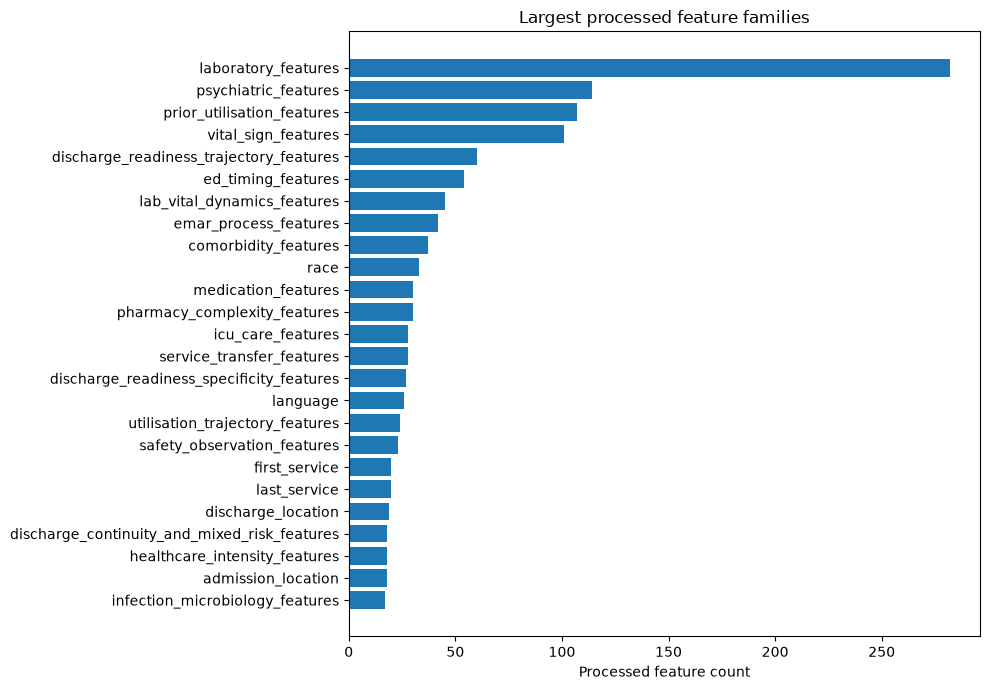

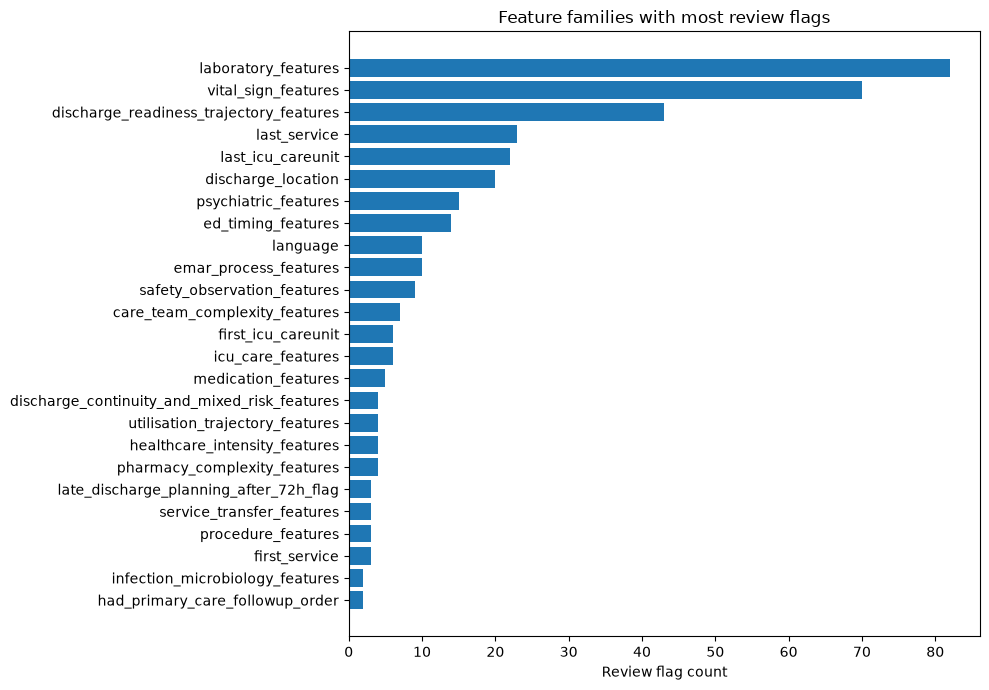

In [22]:
#plot largest feature families by processed feature count
plt.figure(figsize=(10, 7))
plt.barh(largest_feature_families_df["feature_family"][::-1], largest_feature_families_df["processed_feature_count"][::-1])
plt.xlabel("Processed feature count")
plt.title("Largest processed feature families")
plt.tight_layout()
plt.savefig(wp3_feature_audit_output_path / "t3_feature_audit_largest_feature_families.png", dpi=300)
plt.show()

#plot feature families with the most review flags
feature_family_audit_df["total_review_flag_count"] = (
    feature_family_audit_df["all_zero_feature_count"] +
    feature_family_audit_df["very_rare_feature_count"] +
    feature_family_audit_df["timing_leakage_review_count"])
review_plot_df = feature_family_audit_df.sort_values("total_review_flag_count", ascending=False).head(25)

plt.figure(figsize=(10, 7))
plt.barh(review_plot_df["feature_family"][::-1], review_plot_df["total_review_flag_count"][::-1])
plt.xlabel("Review flag count")
plt.title("Feature families with most review flags")
plt.tight_layout()
plt.savefig(wp3_feature_audit_output_path / "t3_feature_audit_feature_family_review_flags.png", dpi=300)
plt.show()

**Save feature audit outputs**

The Excel workbook is intended for manual inspection. The CSV files are saved separately so they can be reused programmatically.

In [23]:
#save feature audit tables
processed_feature_audit_path = wp3_feature_audit_output_path / "t3_feature_audit_processed_features.csv"
feature_family_audit_path = wp3_feature_audit_output_path / "t3_feature_audit_feature_families.csv"
candidate_removal_review_path = wp3_feature_audit_output_path / "t3_feature_audit_candidate_removal_review.csv"
leakage_review_path = wp3_feature_audit_output_path / "t3_feature_audit_timing_leakage_review.csv"
excel_output_path = wp3_feature_audit_output_path / "t3_feature_audit_tables.xlsx"

feature_audit_df.to_csv(processed_feature_audit_path, index=False)
feature_family_audit_df.to_csv(feature_family_audit_path, index=False)
candidate_removal_review_df.to_csv(candidate_removal_review_path, index=False)
leakage_review_df.to_csv(leakage_review_path, index=False)

with pd.ExcelWriter(excel_output_path) as writer:
    feature_audit_df.to_excel(writer, sheet_name="processed_features", index=False)
    feature_family_audit_df.to_excel(writer, sheet_name="feature_families", index=False)
    candidate_removal_review_df.to_excel(writer, sheet_name="candidate_removal_review", index=False)
    leakage_review_df.to_excel(writer, sheet_name="timing_leakage_review", index=False)

print("Saved feature audit tables to:")
print(wp3_feature_audit_output_path)

Saved feature audit tables to:
/Users/ahthini/Desktop/DissProject/outputs/WP3_feature_audit


**Create audit-backed reduced processed matrices**

This section creates the reduced matrices used by later WP3 notebooks. The primary reduced set is not treated as a fixed target feature count. Instead, it starts from the current clean processed matrix, removes unusable outcome-context and zero/near-zero columns, then keeps features that have evidence from the rapid-trial SHAP cycle, recent model importance, or clinically important non-sparse feature families. This gives an audit trail for why features were kept or removed, rather than blindly following the previous 544-feature count.

In [24]:
#create audit-backed reduced processed matrices without overwriting the full wp3.1 matrices
#the full processed matrix remains available. these reduced versions are saved alongside it for downstream wp3 notebooks.
clean_remove_reason_contains = ["direct_future_outcome_remove",
    "all_zero_in_training", "death_or_readmission_impossible_review"]
clean_reason_regex = "|".join(re.escape(reason) for reason in clean_remove_reason_contains)

#clean set: remove features that are clearly unusable, empty, or methodologically awkward for the main benchmark.
clean_drop_features = set(candidate_removal_review_df.loc[
    candidate_removal_review_df["removal_review_reason"].str.contains(clean_reason_regex, na=False),
    "processed_feature_name"])

#catch death/hospice wording explicitly in case upstream category names shift slightly.
explicit_death_hospice_patterns = ["DIED", "HOSPICE", "Hospice / died", "discharged_to_death_or_hospice"]
clean_drop_features.update([feature_name for feature_name in processed_feature_names
    if any(pattern in feature_name for pattern in explicit_death_hospice_patterns)])

#drop very low-yield structured columns that repeatedly appear as all-zero or near-zero in the processed audit.
#these remain available in the full matrix, but they do not need to be carried into routine model runs.
explicit_low_yield_clean_names = {"num__emar_psychotropic_refused_count",
    "num__emar_missed_or_not_given_flag", "num__emar_iv_administration_count",
    "num__had_ciWA_protocol_order", "num__had_alcohol_withdrawal_protocol_order",
    "num__had_methadone_or_buprenorphine", "num__positive_culture_flag",
    "num__polymicrobial_flag", "num__underweight_flag", "num__multiple_icu_stays",
    "num__had_elopement_precaution_order", "num__had_restraint_order",
    "num__had_restraint_related_procedure", "num__had_suicide_precaution_order"}
explicit_low_yield_clean_patterns = ["cat__bmi_category_",
    "cat__lab_abnormal_burden_category_", "cat__unique_drug_burden_category_"]
clean_drop_features.update([feature_name for feature_name in processed_feature_names
    if feature_name in explicit_low_yield_clean_names or
    any(feature_name.startswith(pattern) for pattern in explicit_low_yield_clean_patterns)])

#runtime-trimmed set: clean set plus extremely rare low-signal processed features.
runtime_trim_drop_features = set(clean_drop_features)
runtime_trim_drop_features.update(candidate_removal_review_df.loc[
    candidate_removal_review_df["removal_review_reason"].str.contains("very_rare_and_low_recorded_model_signal", na=False),
    "processed_feature_name"])

#full-record timing/lab/vital features are valid for the full-record benchmark, so do not remove them here solely for timing reasons.
full_record_only_features = set(candidate_removal_review_df.loc[
    candidate_removal_review_df["removal_review_reason"].str.contains("full_record_only_not_for_early_prediction", na=False),
    "processed_feature_name"])
clean_drop_features = clean_drop_features - full_record_only_features
runtime_trim_drop_features = runtime_trim_drop_features - full_record_only_features

#save reduced matrix set
def save_reduced_matrix_set(drop_features, output_suffix):
    keep_feature_mask = np.array([feature_name not in drop_features for feature_name in processed_feature_names])
    kept_processed_feature_names = np.array(processed_feature_names)[keep_feature_mask]
    removed_processed_feature_names = sorted(drop_features)

    X_train_reduced = X_train[:, keep_feature_mask]
    X_test_reduced = X_test[:, keep_feature_mask]

    #loop through each item in this feature block
    for reduced_output_path in [wp3_feature_audit_output_path, wp3_1_output_path]:
        #save this table or artefact for later review
        sparse.save_npz(reduced_output_path / f"t3_1_X_train_processed_{output_suffix}.npz", X_train_reduced)
        sparse.save_npz(reduced_output_path / f"t3_1_X_test_processed_{output_suffix}.npz", X_test_reduced)
        pd.DataFrame({"processed_feature_name": kept_processed_feature_names}).to_csv(
            reduced_output_path / f"t3_1_processed_feature_names_{output_suffix}.csv", index=False)
        pd.DataFrame({"processed_feature_name": removed_processed_feature_names}).to_csv(
            reduced_output_path / f"t3_1_removed_processed_feature_names_{output_suffix}.csv", index=False)

    return {"matrix_set": output_suffix,
        "original_training_features": X_train.shape[1],
        "reduced_training_features": X_train_reduced.shape[1],
        "removed_processed_features": len(removed_processed_feature_names),
        "training_rows": X_train_reduced.shape[0],
        "test_rows": X_test_reduced.shape[0],
        "training_nonzero_values": X_train_reduced.nnz,
        "test_nonzero_values": X_test_reduced.nnz}

reduced_matrix_summary_df = pd.DataFrame([
    save_reduced_matrix_set(clean_drop_features, "clean_feature_audit"),
    save_reduced_matrix_set(runtime_trim_drop_features, "runtime_trimmed_feature_audit")])

removed_clean_df = pd.DataFrame({"processed_feature_name": sorted(clean_drop_features), "removal_set": "clean_feature_audit"})
removed_runtime_trim_df = pd.DataFrame({"processed_feature_name": sorted(runtime_trim_drop_features), "removal_set": "runtime_trimmed_feature_audit"})
recommended_removed_features_df = pd.concat([removed_clean_df, removed_runtime_trim_df], ignore_index=True)

#save this table or artefact for later review
reduced_matrix_summary_df.to_csv(wp3_feature_audit_output_path / "t3_feature_audit_reduced_matrix_summary.csv", index=False)
recommended_removed_features_df.to_csv(wp3_feature_audit_output_path / "t3_feature_audit_recommended_removed_features.csv", index=False)

print("Recommended reduced matrix summary:")
print(reduced_matrix_summary_df)
print()
print("Clean removed features:", len(clean_drop_features))
print("Runtime-trimmed removed features:", len(runtime_trim_drop_features))

#primary shap-guided set: rebuild from the current clean matrix, with transparent keep/remove evidence.
shap_guided_feature_list_file = output_path / "WP3_rapid_trial" / "tables" / "rapid_trial_rebuilt_reduced_feature_names.xlsx"
shap_global_importance_file = output_path / "WP3_rapid_trial" / "tables" / "rapid_trial_shap_global_importance.xlsx"
feature_family_importance_file = output_path / "WP3_rapid_trial" / "tables" / "rapid_trial_feature_family_importance.xlsx"
shap_guided_output_suffix = "shap_guided_reduced_feature_set"

current_clean_feature_names_file = wp3_1_output_path / "t3_1_processed_feature_names_clean_feature_audit.csv"
current_clean_train_file = wp3_1_output_path / "t3_1_X_train_processed_clean_feature_audit.npz"
current_clean_test_file = wp3_1_output_path / "t3_1_X_test_processed_clean_feature_audit.npz"

#recent clinically motivated families are kept only when they are present and not near-zero in the current clean matrix.
#these explicit add-backs came from wp3.5/wp4 error analysis and a raw-table coverage check:
#aftercare/support features plus compact structured features from poe detail, hcpcs, pharmacy, emar, and icu status fields.
explicit_primary_addback_features = {
    "num__protective_aftercare_present_flag",
    "num__low_aftercare_quality_flag",
    "num__home_discharge_without_followup_order_flag",
    "num__home_discharge_without_discharge_planning_order_flag",
    "num__psychosis_home_discharge_no_followup_flag",
    "num__smi_home_discharge_no_followup_flag",
    "num__substance_use_home_discharge_no_followup_flag",
    "num__num_code_status_orders",
    "num__had_code_status_change_order",
    "num__num_discharge_when_orders",
    "num__had_discharge_now_order",
    "num__num_transfer_to_orders",
    "num__num_level_of_urgency_orders",
    "num__urgent_order_flag",
    "num__routine_order_flag",
    "num__num_hospital_observation_hcpcs_events",
    "num__num_emergency_hcpcs_events",
    "num__num_therapy_hcpcs_events",
    "num__num_rehab_hcpcs_events",
    "num__hcpcs_observation_to_total_ratio",
    "num__num_floor_stock_pharmacy_orders",
    "num__num_patient_may_take_own_med_orders",
    "num__num_dosing_by_pharmacy_orders",
    "num__num_discharge_med_proc_type_orders",
    "num__pharmacy_logistics_complexity_score",
    "num__num_delayed_administered_events",
    "num__delayed_administered_rate",
    "num__num_started_emar_events",
    "num__num_stopped_emar_events",
    "num__emar_started_stopped_activity_last_24h",
    "num__emar_delayed_or_not_given_last_24h",
    "num__num_icu_procedure_events",
    "num__num_paused_inputevents",
    "num__num_stopped_inputevents",
    "num__num_change_dose_rate_inputevents",
    "num__num_paused_procedureevents",
    "num__num_stopped_procedureevents",
    "num__icu_event_interruption_score"}

clinically_relevant_extra_patterns = [
    "late_", "last_6h", "last_12h", "near_discharge", "before_discharge",
    "aftercare", "followup", "discharge_planning", "safety", "urgency", "code_status",
    "hospital_observation", "hcpcs", "dispensation", "logistics", "delayed_administered",
    "started_emar", "stopped_emar", "paused_inputevents", "stopped_inputevents",
    "change_dose_rate", "paused_procedureevents", "stopped_procedureevents", "quiet_risk",
    "unmanaged", "protective", "continuity", "home_discharge_without", "home_discharge_with",
    "low_aftercare", "medical_complexity_no_aftercare", "ed_only", "previous_admission",
    "emar", "pharmacy", "psychotropic", "antipsychotic", "benzodiazepine", "mood_stabiliser",
    "polypharmacy", "no_late_orders_but", "low_order_activity", "self_harm_without",
    "psychosis_without", "smi_without", "previous_total_admissions_", "previous_psych_admissions_",
    "previous_nonpsych_admissions_", "previous_ed_visits_", "previous_icu_admissions_",
    "recent_icu_admission_"]

if shap_guided_feature_list_file.exists() and current_clean_feature_names_file.exists() and current_clean_train_file.exists() and current_clean_test_file.exists():
    shap_guided_feature_names_df = pd.read_excel(shap_guided_feature_list_file)
    shap_guided_requested_features = shap_guided_feature_names_df["processed_feature_name"].dropna().astype(str).tolist()
    shap_guided_requested_set = set(shap_guided_requested_features)

    current_clean_feature_names = pd.read_csv(current_clean_feature_names_file)["processed_feature_name"].astype(str).tolist()
    current_clean_feature_set = set(current_clean_feature_names)
    current_clean_feature_index = {feature_name: index for index, feature_name in enumerate(current_clean_feature_names)}
    X_train_clean = sparse.load_npz(current_clean_train_file)
    X_test_clean = sparse.load_npz(current_clean_test_file)

    #sparsity is calculated on the clean matrix so the primary reduced matrix reflects the current train/test split.
    clean_train_nonzero_count = np.asarray(X_train_clean.getnnz(axis=0)).ravel()
    clean_test_nonzero_count = np.asarray(X_test_clean.getnnz(axis=0)).ravel()
    clean_selection_df = pd.DataFrame({
        "processed_feature_name": current_clean_feature_names,
        "clean_train_nonzero_count": clean_train_nonzero_count,
        "clean_test_nonzero_count": clean_test_nonzero_count})
    clean_selection_df["clean_train_nonzero_percent"] = 100 * clean_selection_df["clean_train_nonzero_count"] / X_train_clean.shape[0]
    clean_selection_df["clean_test_nonzero_percent"] = 100 * clean_selection_df["clean_test_nonzero_count"] / X_test_clean.shape[0]
    clean_selection_df["all_zero_train"] = clean_selection_df["clean_train_nonzero_count"].eq(0)
    clean_selection_df["near_zero_train"] = clean_selection_df["clean_train_nonzero_percent"].lt(0.05)
    clean_selection_df["core_rapid_trial_keep"] = clean_selection_df["processed_feature_name"].isin(shap_guided_requested_set)
    clean_selection_df["clinically_relevant_extra_candidate"] = clean_selection_df["processed_feature_name"].apply(
        lambda feature_name: any(pattern.lower() in feature_name.lower() for pattern in clinically_relevant_extra_patterns))
    clean_selection_df["explicit_aftercare_addback_candidate"] = clean_selection_df["processed_feature_name"].isin(explicit_primary_addback_features)

    if shap_global_importance_file.exists():
        shap_global_df = pd.read_excel(shap_global_importance_file)
        if "processed_feature_name" in shap_global_df.columns:
            shap_score_col = next((col for col in ["mean_abs_shap", "importance", "feature_importance"] if col in shap_global_df.columns), None)
            if shap_score_col is not None:
                shap_global_df = shap_global_df[["processed_feature_name", shap_score_col]].rename(columns={shap_score_col: "rapid_trial_mean_abs_shap"})
                #join the derived features back to the admission table
                clean_selection_df = clean_selection_df.merge(shap_global_df, on="processed_feature_name", how="left")
    if "rapid_trial_mean_abs_shap" not in clean_selection_df.columns:
        clean_selection_df["rapid_trial_mean_abs_shap"] = np.nan

    high_signal_cutoff = clean_selection_df["rapid_trial_mean_abs_shap"].quantile(0.80) if clean_selection_df["rapid_trial_mean_abs_shap"].notna().any() else np.nan
    clean_selection_df["high_recent_shap_signal"] = clean_selection_df["rapid_trial_mean_abs_shap"].ge(high_signal_cutoff).fillna(False)
    clean_selection_df["extra_keep_after_sparsity_check"] = (
        (clean_selection_df["clinically_relevant_extra_candidate"] | clean_selection_df["explicit_aftercare_addback_candidate"]) &
        ~clean_selection_df["all_zero_train"] &
        ~clean_selection_df["near_zero_train"])

    #selection rule: keep the rapid-trial core, high-signal current features, and clinically relevant non-sparse extras.
    clean_selection_df["keep_in_primary_reduced_matrix"] = (
        clean_selection_df["core_rapid_trial_keep"] |
        clean_selection_df["high_recent_shap_signal"] |
        clean_selection_df["extra_keep_after_sparsity_check"])
    clean_selection_df.loc[clean_selection_df["all_zero_train"], "keep_in_primary_reduced_matrix"] = False

    #define reduced selection reason
    def reduced_selection_reason(row):
        reasons = []
        if row["all_zero_train"]:
            reasons.append("removed_all_zero_train")
        if row["near_zero_train"] and not row["core_rapid_trial_keep"]:
            reasons.append("removed_near_zero_unless_core")
        if row["core_rapid_trial_keep"]:
            reasons.append("kept_rapid_trial_core")
        if row["high_recent_shap_signal"]:
            reasons.append("kept_high_recent_shap_signal")
        if row["extra_keep_after_sparsity_check"]:
            reasons.append("kept_clinically_relevant_non_sparse_extra")
        if not reasons:
            reasons.append("removed_not_selected_by_signal_or_family_rule")
        return "; ".join(reasons)

    clean_selection_df["primary_reduced_selection_reason"] = clean_selection_df.apply(reduced_selection_reason, axis=1)
    kept_shap_guided_features = clean_selection_df.loc[
        clean_selection_df["keep_in_primary_reduced_matrix"], "processed_feature_name"].tolist()
    removed_shap_guided_features = clean_selection_df.loc[
        ~clean_selection_df["keep_in_primary_reduced_matrix"], "processed_feature_name"].tolist()
    missing_shap_guided_features = sorted(shap_guided_requested_set - current_clean_feature_set)

    if not kept_shap_guided_features:
        raise ValueError("No audit-backed reduced features matched the current clean matrix.")

    shap_guided_keep_indices = [current_clean_feature_index[feature_name] for feature_name in kept_shap_guided_features]
    X_train_shap_guided = X_train_clean[:, shap_guided_keep_indices]
    X_test_shap_guided = X_test_clean[:, shap_guided_keep_indices]

    shap_guided_summary_df = pd.DataFrame([
        {"field": "source_matrix_suffix", "value": "clean_feature_audit"},
        {"field": "rebuilt_matrix_suffix", "value": shap_guided_output_suffix},
        {"field": "core_requested_feature_count", "value": len(shap_guided_requested_features)},
        {"field": "high_recent_shap_signal_feature_count", "value": int(clean_selection_df["high_recent_shap_signal"].sum())},
        {"field": "clinically_relevant_non_sparse_extra_count", "value": int(clean_selection_df["extra_keep_after_sparsity_check"].sum())},
        {"field": "explicit_aftercare_addback_feature_count", "value": int((clean_selection_df["explicit_aftercare_addback_candidate"] & clean_selection_df["keep_in_primary_reduced_matrix"]).sum())},
        {"field": "missing_core_requested_features", "value": len(missing_shap_guided_features)},
        {"field": "original_clean_feature_count", "value": len(current_clean_feature_names)},
        {"field": "primary_reduced_feature_count", "value": X_train_shap_guided.shape[1]},
        {"field": "dropped_feature_count", "value": len(removed_shap_guided_features)},
        {"field": "all_zero_features_removed", "value": int((~clean_selection_df["keep_in_primary_reduced_matrix"] & clean_selection_df["all_zero_train"]).sum())},
        {"field": "near_zero_features_removed", "value": int((~clean_selection_df["keep_in_primary_reduced_matrix"] & clean_selection_df["near_zero_train"]).sum())},
        {"field": "training_rows", "value": X_train_shap_guided.shape[0]},
        {"field": "test_rows", "value": X_test_shap_guided.shape[0]}])

    for reduced_output_path in [wp3_1_output_path, wp3_feature_audit_output_path]:
        sparse.save_npz(reduced_output_path / f"t3_1_X_train_processed_{shap_guided_output_suffix}.npz", X_train_shap_guided)
        sparse.save_npz(reduced_output_path / f"t3_1_X_test_processed_{shap_guided_output_suffix}.npz", X_test_shap_guided)
        pd.DataFrame({"processed_feature_name": kept_shap_guided_features}).to_csv(
            reduced_output_path / f"t3_1_processed_feature_names_{shap_guided_output_suffix}.csv", index=False)
        pd.DataFrame({"processed_feature_name": removed_shap_guided_features}).to_csv(
            reduced_output_path / f"t3_1_removed_processed_feature_names_{shap_guided_output_suffix}.csv", index=False)
        shap_guided_summary_df.to_csv(
            reduced_output_path / f"t3_1_rebuilt_reduced_matrix_summary_{shap_guided_output_suffix}.csv", index=False)
        clean_selection_df.to_csv(
            reduced_output_path / f"t3_1_primary_reduced_feature_selection_audit_{shap_guided_output_suffix}.csv", index=False)
        if missing_shap_guided_features:
            pd.DataFrame({"processed_feature_name": missing_shap_guided_features}).to_csv(
                reduced_output_path / f"t3_1_missing_requested_features_{shap_guided_output_suffix}.csv", index=False)

    print("Rebuilt audit-backed SHAP-guided reduced feature set from current clean matrix:")
    print(shap_guided_summary_df)
    print("Selection audit saved as:")
    print(wp3_1_output_path / f"t3_1_primary_reduced_feature_selection_audit_{shap_guided_output_suffix}.csv")
else:
    print("SHAP-guided reduced matrix rebuild skipped because one or more inputs were unavailable.")
    print("Expected rapid-trial list:", shap_guided_feature_list_file)
    print("Expected clean matrix files:", current_clean_feature_names_file, current_clean_train_file, current_clean_test_file)

#review candidate missing feature groups against the engineered data, full processed matrix, and primary reduced matrix.
#this helps distinguish genuinely unavailable domains from features that were engineered but removed for sparsity or low signal.
engineered_dataset_path = output_path / "t2_3_engineered_dataset.csv"
if engineered_dataset_path.exists():
    engineered_columns = pd.read_csv(engineered_dataset_path, nrows=0).columns.astype(str).tolist()
    engineered_column_set = set(engineered_columns)
    full_processed_feature_set = set(processed_feature_names)
    primary_reduced_feature_set = set(kept_shap_guided_features) if "kept_shap_guided_features" in globals() else set()

    #define strip processed prefix
    def strip_processed_prefix(feature_name):
        return re.sub(r"^(num__|cat__)", "", str(feature_name))

    full_processed_base_set = {strip_processed_prefix(feature_name) for feature_name in full_processed_feature_set}
    primary_reduced_base_set = {strip_processed_prefix(feature_name) for feature_name in primary_reduced_feature_set}

    candidate_feature_groups = {
        "true_ed_only_and_crisis_contacts": [
            "previous_ed_visits_without_admission_30d", "previous_ed_visits_without_admission_90d",
            "prior_ed_only_high_use_flag", "ed_visit_to_admission_ratio_365d"],
        "aftercare_and_discharge_support": [
            "aftercare_quality_score", "protective_aftercare_present_flag", "low_aftercare_quality_flag",
            "home_discharge_without_followup_order_flag", "home_discharge_without_discharge_planning_order_flag",
            "psychosis_home_discharge_no_followup_flag", "smi_home_discharge_no_followup_flag",
            "substance_use_home_discharge_no_followup_flag", "self_harm_no_psych_followup_flag"],
        "placement_and_social_barrier_orders": [
            "placement_related_order_flag", "awaiting_bed_or_placement_flag", "transport_delay_order_flag",
            "social_barrier_order_flag", "delayed_discharge_planning_flag"],
        "discharge_medication_continuity": [
            "discharge_medication_continuity_score", "no_psychotropic_discharge_med_in_psychosis_flag",
            "smi_without_psychotropic_continuity_flag", "home_discharge_without_medication_or_followup_plan_flag"],
        "notes_and_narrative_risk": [
            "discharge_note_text", "psychiatric_risk_assessment_text", "mental_state_exam_text",
            "housing_instability_text", "family_support_text"],
        "occupation_and_richer_social_context": [
            "occupation", "employment_status", "education_level", "income", "living_arrangement",
            "housing_status", "caregiver_availability"],
        "outpatient_community_followup_actual": [
            "community_mental_health_contact", "outpatient_appointment_attended", "crisis_team_contact",
            "post_discharge_medication_fill", "primary_care_followup_attended"]}

    missing_feature_review_rows = []
    for group_name, candidate_features in candidate_feature_groups.items():
        #loop through each item in this feature block
        for feature_name in candidate_features:
            engineered_available = feature_name in engineered_column_set
            full_processed_available = feature_name in full_processed_base_set
            primary_reduced_available = feature_name in primary_reduced_base_set
            nonzero_count = np.nan
            nonzero_percent = np.nan
            unique_values = np.nan
            if engineered_available:
                feature_values = pd.read_csv(engineered_dataset_path, usecols=[feature_name])[feature_name]
                numeric_values = pd.to_numeric(feature_values, errors="coerce")
                nonzero_count = int((numeric_values.fillna(0) != 0).sum())
                nonzero_percent = 100 * nonzero_count / len(numeric_values)
                unique_values = int(feature_values.nunique(dropna=True))
            if not engineered_available:
                recommendation = "not_available_in_current_structured_extract"
            elif nonzero_count == 0:
                recommendation = "engineered_but_all_zero_do_not_add_as_is"
            elif primary_reduced_available:
                recommendation = "already_in_primary_reduced_matrix"
            elif full_processed_available and nonzero_percent < 0.05:
                recommendation = "available_but_near_zero_not_recommended"
            elif full_processed_available:
                recommendation = "available_not_in_primary_reduced_consider_targeted_reduced_plus_test"
            else:
                recommendation = "engineered_but_not_processed_check_preprocessor_columns"

            missing_feature_review_rows.append({
                "feature_group": group_name,
                "candidate_feature": feature_name,
                "engineered_available": engineered_available,
                "full_processed_available": full_processed_available,
                "primary_reduced_available": primary_reduced_available,
                "engineered_nonzero_count": nonzero_count,
                "engineered_nonzero_percent": nonzero_percent,
                "engineered_unique_values": unique_values,
                "recommendation": recommendation})

    missing_feature_review_df = pd.DataFrame(missing_feature_review_rows)
    #save this table or artefact for later review
    missing_feature_review_df.to_csv(wp3_feature_audit_output_path / "t3_feature_audit_missing_feature_group_review.csv", index=False)
    missing_feature_review_df.to_csv(wp3_1_output_path / "t3_1_missing_feature_group_review.csv", index=False)

    print("Missing/addable feature group review:")
    display(missing_feature_review_df.sort_values(["recommendation", "feature_group", "candidate_feature"]))
else:
    print("Missing feature group review skipped because engineered dataset was not found:", engineered_dataset_path)

Recommended reduced matrix summary:
                      matrix_set  original_training_features  reduced_training_features  removed_processed_features  training_rows  test_rows  training_nonzero_values  \
0            clean_feature_audit                        1688                       1618                          70         191320      47171                262682360   
1  runtime_trimmed_feature_audit                        1688                       1588                         100         191320      47171                262681562   

   test_nonzero_values  
0             64765783  
1             64765573  

Clean removed features: 70
Runtime-trimmed removed features: 100
Rebuilt audit-backed SHAP-guided reduced feature set from current clean matrix:
                                         field                            value
0                         source_matrix_suffix              clean_feature_audit
1                        rebuilt_matrix_suffix  shap_guided_reduced_feat

,feature_group,candidate_feature,engineered_available,full_processed_available,primary_reduced_available,engineered_nonzero_count,engineered_nonzero_percent,engineered_unique_values,recommendation
4,aftercare_and_discharge_support,aftercare_quality_score,True,True,True,208961.0,87.617981,6.0,already_in_primary_reduced_matrix
8,aftercare_and_discharge_support,home_discharge_without_discharge_planning_orde...,True,True,True,1584.0,0.664176,2.0,already_in_primary_reduced_matrix
7,aftercare_and_discharge_support,home_discharge_without_followup_order_flag,True,True,True,41884.0,17.562088,2.0,already_in_primary_reduced_matrix
6,aftercare_and_discharge_support,low_aftercare_quality_flag,True,True,True,29530.0,12.382019,2.0,already_in_primary_reduced_matrix
5,aftercare_and_discharge_support,protective_aftercare_present_flag,True,True,True,172750.0,72.434599,2.0,already_in_primary_reduced_matrix
9,aftercare_and_discharge_support,psychosis_home_discharge_no_followup_flag,True,True,True,3159.0,1.324578,2.0,already_in_primary_reduced_matrix
12,aftercare_and_discharge_support,self_harm_no_psych_followup_flag,True,True,True,18927.0,7.936149,2.0,already_in_primary_reduced_matrix
10,aftercare_and_discharge_support,smi_home_discharge_no_followup_flag,True,True,True,8938.0,3.747731,2.0,already_in_primary_reduced_matrix
11,aftercare_and_discharge_support,substance_use_home_discharge_no_followup_flag,True,True,True,16862.0,7.070288,2.0,already_in_primary_reduced_matrix
18,discharge_medication_continuity,discharge_medication_continuity_score,True,True,True,157773.0,66.154698,5.0,already_in_primary_reduced_matrix


**refresh feature audit output file summary**

The output file summary is refreshed after reduced matrices are created so the additional sensitivity files are recorded alongside the audit tables.


In [25]:
#refresh output file summary after creating audit and reduced matrix files
feature_audit_output_files = []
for output_file in sorted(wp3_feature_audit_output_path.iterdir()):
    if output_file.is_file():
        feature_audit_output_files.append({
            "output_folder": "WP3_feature_audit",
            "output_file": output_file.name,
            "file_size_mb": round(output_file.stat().st_size / (1024 ** 2), 3)})

feature_audit_output_file_summary_df = pd.DataFrame(feature_audit_output_files)
feature_audit_output_file_summary_df.to_csv(
    wp3_feature_audit_output_path / "t3_feature_audit_output_file_summary.csv", index=False)

print("WP3 feature audit output files:")
print(feature_audit_output_file_summary_df)

WP3 feature audit output files:
        output_folder                                        output_file  file_size_mb
0   WP3_feature_audit      t3_1_X_test_processed_clean_feature_audit.npz       146.988
1   WP3_feature_audit  t3_1_X_test_processed_runtime_trimmed_feature_...       147.013
2   WP3_feature_audit  t3_1_X_test_processed_shap_guided_reduced_feat...       106.033
3   WP3_feature_audit     t3_1_X_train_processed_clean_feature_audit.npz       594.923
4   WP3_feature_audit  t3_1_X_train_processed_runtime_trimmed_feature...       595.021
5   WP3_feature_audit  t3_1_X_train_processed_shap_guided_reduced_fea...       429.521
6   WP3_feature_audit  t3_1_primary_reduced_feature_selection_audit_s...         0.270
7   WP3_feature_audit  t3_1_processed_feature_names_clean_feature_aud...         0.056
8   WP3_feature_audit  t3_1_processed_feature_names_runtime_trimmed_f...         0.055
9   WP3_feature_audit  t3_1_processed_feature_names_shap_guided_reduc...         0.034
10  WP3_fea

**Create output file summary**

The final summary records all files created by the feature audit notebook.

In [26]:
#summarise output files created by this notebook
feature_audit_output_files = sorted(wp3_feature_audit_output_path.glob("t3_feature_audit*")) + sorted(wp3_feature_audit_output_path.glob("t3_1_*feature_audit*"))
feature_audit_output_summary_df = pd.DataFrame([{"output_folder": path.parent.name,
     "output_file": path.name, "file_size_mb": round(path.stat().st_size / (1024 ** 2), 3)}
    for path in feature_audit_output_files])

feature_audit_output_summary_path = wp3_feature_audit_output_path / "t3_feature_audit_output_file_summary.csv"
feature_audit_output_summary_df.to_csv(feature_audit_output_summary_path, index=False)
print("WP3 feature audit output files:")
print(feature_audit_output_summary_df)
print("\nWP3 feature audit complete. Outputs saved to:")
print(wp3_feature_audit_output_path)

WP3 feature audit output files:
        output_folder                                        output_file  file_size_mb
0   WP3_feature_audit      t3_feature_audit_candidate_removal_review.csv         0.114
1   WP3_feature_audit              t3_feature_audit_feature_families.csv         0.019
2   WP3_feature_audit   t3_feature_audit_feature_family_review_flags.png         0.253
3   WP3_feature_audit      t3_feature_audit_largest_feature_families.png         0.244
4   WP3_feature_audit  t3_feature_audit_missing_feature_group_review.csv         0.005
5   WP3_feature_audit           t3_feature_audit_output_file_summary.csv         0.002
6   WP3_feature_audit            t3_feature_audit_processed_features.csv         0.505
7   WP3_feature_audit  t3_feature_audit_recommended_removed_features.csv         0.010
8   WP3_feature_audit        t3_feature_audit_reduced_matrix_summary.csv         0.000
9   WP3_feature_audit                       t3_feature_audit_tables.xlsx         0.346
10  WP3_fea

**Final WP3.1 audit summary**

A final summary is produced to confirm that the modelling split and preprocessing outputs were generated correctly.

In [27]:
#set file paths and create output folders
wp3_1_summary = pd.DataFrame({"check": ["Source engineered dataset", "Source dataset modified time",
        "Rows in source engineered dataset", "Original predictor columns", "Processed predictor columns",
        "Training admissions", "Test admissions", "Training patients",
        "Test patients", "Patient overlap between train and test",
        "Training readmission rate (%)", "Test readmission rate (%)", "Modelling context"],
    "value": [str(engineered_dataset_file), source_dataset_metadata["source_dataset_modified_time"],
        df.shape[0], len(feature_cols), len(processed_feature_names),
        X_train.shape[0], X_test.shape[0], train_ids["subject_id"].nunique(),
        test_ids["subject_id"].nunique(),
        len(set(train_ids["subject_id"]).intersection(set(test_ids["subject_id"]))),
        round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2), "full_record_benchmark"]})

print("WP3.1 modelling preparation audit summary:")
print(wp3_1_summary)
wp3_1_summary.to_csv(wp3_1_output_path / "t3_1_modelling_preparation_summary.csv", index=False)

WP3.1 modelling preparation audit summary:
                                     check                                              value
0                Source engineered dataset  /Users/ahthini/Desktop/DissProject/outputs/t2_...
1             Source dataset modified time                      2026-08-25T17:00:39.323887348
2        Rows in source engineered dataset                                             238491
3               Original predictor columns                                               1435
4              Processed predictor columns                                               1688
5                      Training admissions                                             191320
6                          Test admissions                                              47171
7                        Training patients                                              86340
8                            Test patients                                              21586
9   Patient overl

**Consolidated CSV Table Workbook**

This cell keeps the individual CSV files and also creates one Excel workbook where each CSV table is available as a separate sheet. The workbook is for easier review and sharing; the CSV files remain the primary machine-readable outputs.


In [ ]:
#compile csv tables into one workbook while preserving the original csv files
possible_output_roots = []
#loop through each item in this feature block
for output_name in ['wp3_1_output_path', 'wp3_feature_audit_output_path']:
    if output_name in globals():
        output_root = globals()[output_name]
        if isinstance(output_root, Path) and output_root.exists() and output_root not in possible_output_roots:
            possible_output_roots.append(output_root)

if not possible_output_roots:
    print("no wp3 output roots were available for workbook compilation")
else:
    primary_output_root = possible_output_roots[0]
    workbook_path = primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook.xlsx"
    csv_paths = []
    #loop through each item in this feature block
    for output_root in possible_output_roots:
        csv_paths.extend(sorted(path for path in output_root.rglob("*.csv") if path.is_file()))
    csv_paths = sorted(dict.fromkeys(csv_paths))

    #make sheet name
    def make_sheet_name(csv_path, used_names):
        relative_name = csv_path.relative_to(primary_output_root.parent).with_suffix("").as_posix()
        relative_name = re.sub(r"[^0-9a-zA-Z]+", "_", relative_name).strip("_").lower()
        parts = [part for part in relative_name.split("_") if part not in ["outputs", primary_output_root.name.lower(), "csv", "tables"]]
        base_name = "_".join(parts[-4:]) if parts else csv_path.stem.lower()
        base_name = base_name[:31] or "table"
        sheet_name = base_name
        counter = 1
        while sheet_name in used_names:
            suffix = f"_{counter}"
            sheet_name = base_name[:31 - len(suffix)] + suffix
            counter += 1
        used_names.add(sheet_name)
        return sheet_name

    workbook_index_rows = []
    used_sheet_names = set()
    max_excel_rows = 200000
    with pd.ExcelWriter(workbook_path) as writer:
        #loop through each item in this feature block
        for csv_path in csv_paths:
            try:
                table_df = pd.read_csv(csv_path)
            except Exception as error:
                workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": "", "rows": np.nan,
                    "columns": np.nan, "rows_written": 0, "note": f"read_failed: {error}"})
                continue
            sheet_name = make_sheet_name(csv_path, used_sheet_names)
            rows_written = min(len(table_df), max_excel_rows)
            #save this table or artefact for later review
            table_df.head(max_excel_rows).to_excel(writer, sheet_name=sheet_name, index=False)
            workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": sheet_name, "rows": len(table_df),
                "columns": table_df.shape[1], "rows_written": rows_written,
                "note": "truncated_for_excel" if len(table_df) > max_excel_rows else "complete"})
        workbook_index_df = pd.DataFrame(workbook_index_rows)
        #save this table or artefact for later review
        workbook_index_df.to_excel(writer, sheet_name="workbook_index", index=False)
    #save this table or artefact for later review
    workbook_index_df.to_csv(primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook_index.csv", index=False)
    print("csv table workbook saved to:")
    print(workbook_path)
    display(workbook_index_df)

csv table workbook saved to:
/Users/ahthini/Desktop/DissProject/outputs/WP3_1/wp3_1_csv_table_workbook.xlsx


,csv_path,sheet_name,rows,columns,rows_written,note
0,/Users/ahthini/Desktop/DissProject/outputs/WP3...,1_class_weight_summary,4,2,4,complete
1,/Users/ahthini/Desktop/DissProject/outputs/WP3...,clean_feature_audit_summary,6,2,6,complete
2,/Users/ahthini/Desktop/DissProject/outputs/WP3...,t3_1_methodological_audit,16,2,16,complete
3,/Users/ahthini/Desktop/DissProject/outputs/WP3...,missing_feature_group_review,39,9,39,complete
4,/Users/ahthini/Desktop/DissProject/outputs/WP3...,guided_reduced_feature_set,23,1,23,complete
5,/Users/ahthini/Desktop/DissProject/outputs/WP3...,1_modelling_preparation_summary,13,2,13,complete
6,/Users/ahthini/Desktop/DissProject/outputs/WP3...,guided_reduced_feature_set_1,1618,15,1618,complete
7,/Users/ahthini/Desktop/DissProject/outputs/WP3...,1_processed_feature_names,1688,1,1688,complete
8,/Users/ahthini/Desktop/DissProject/outputs/WP3...,names_clean_feature_audit,1618,1,1618,complete
9,/Users/ahthini/Desktop/DissProject/outputs/WP3...,runtime_trimmed_feature_audit,1588,1,1588,complete
